In [2]:
from brian2 import *
import matplotlib.pyplot as plt
import numpy as np

JÄRGMINE ON SEE ÕIGE

Thalamic→Cortical synapses: 6786
Avg thalamic inputs per cortical neuron: 135.7
Cortical dv/dt at rest with I=50pA: -15.50 mV/ms
Cortical E:    20.9 Hz
LO Thalamic:   49.9 Hz
Interneuron:   70.9 Hz
HO Thalamic:   62.1 Hz


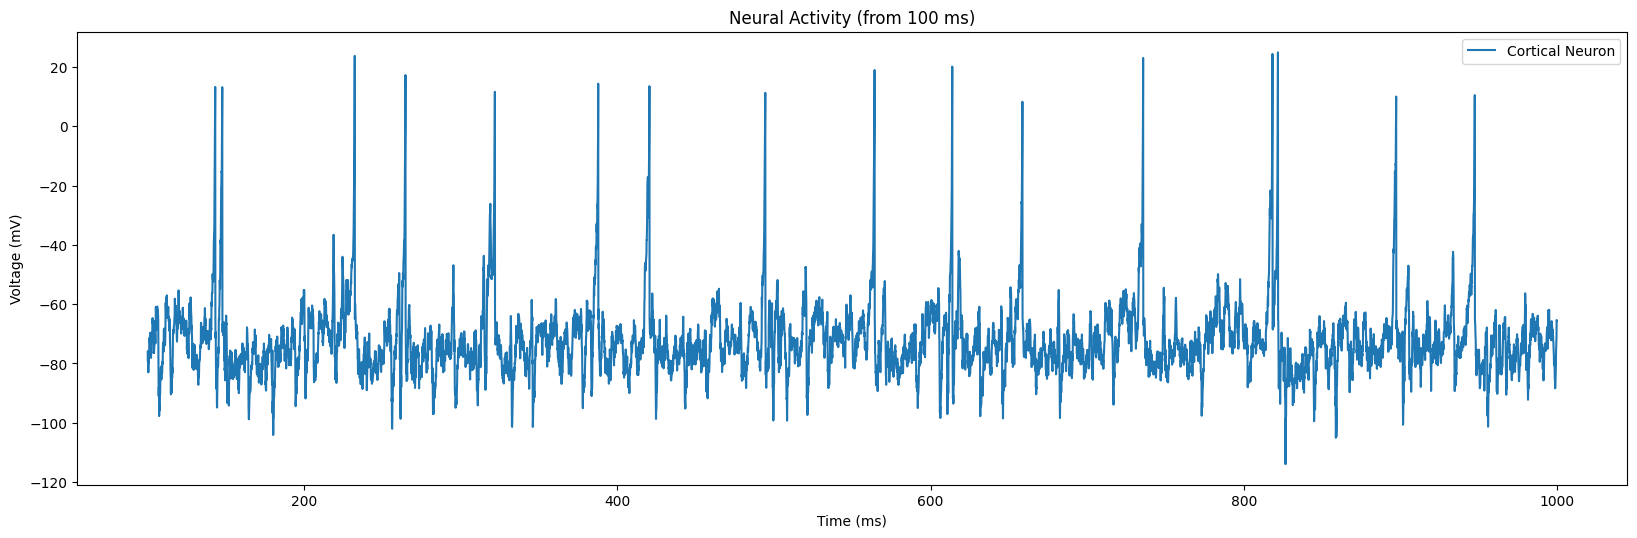

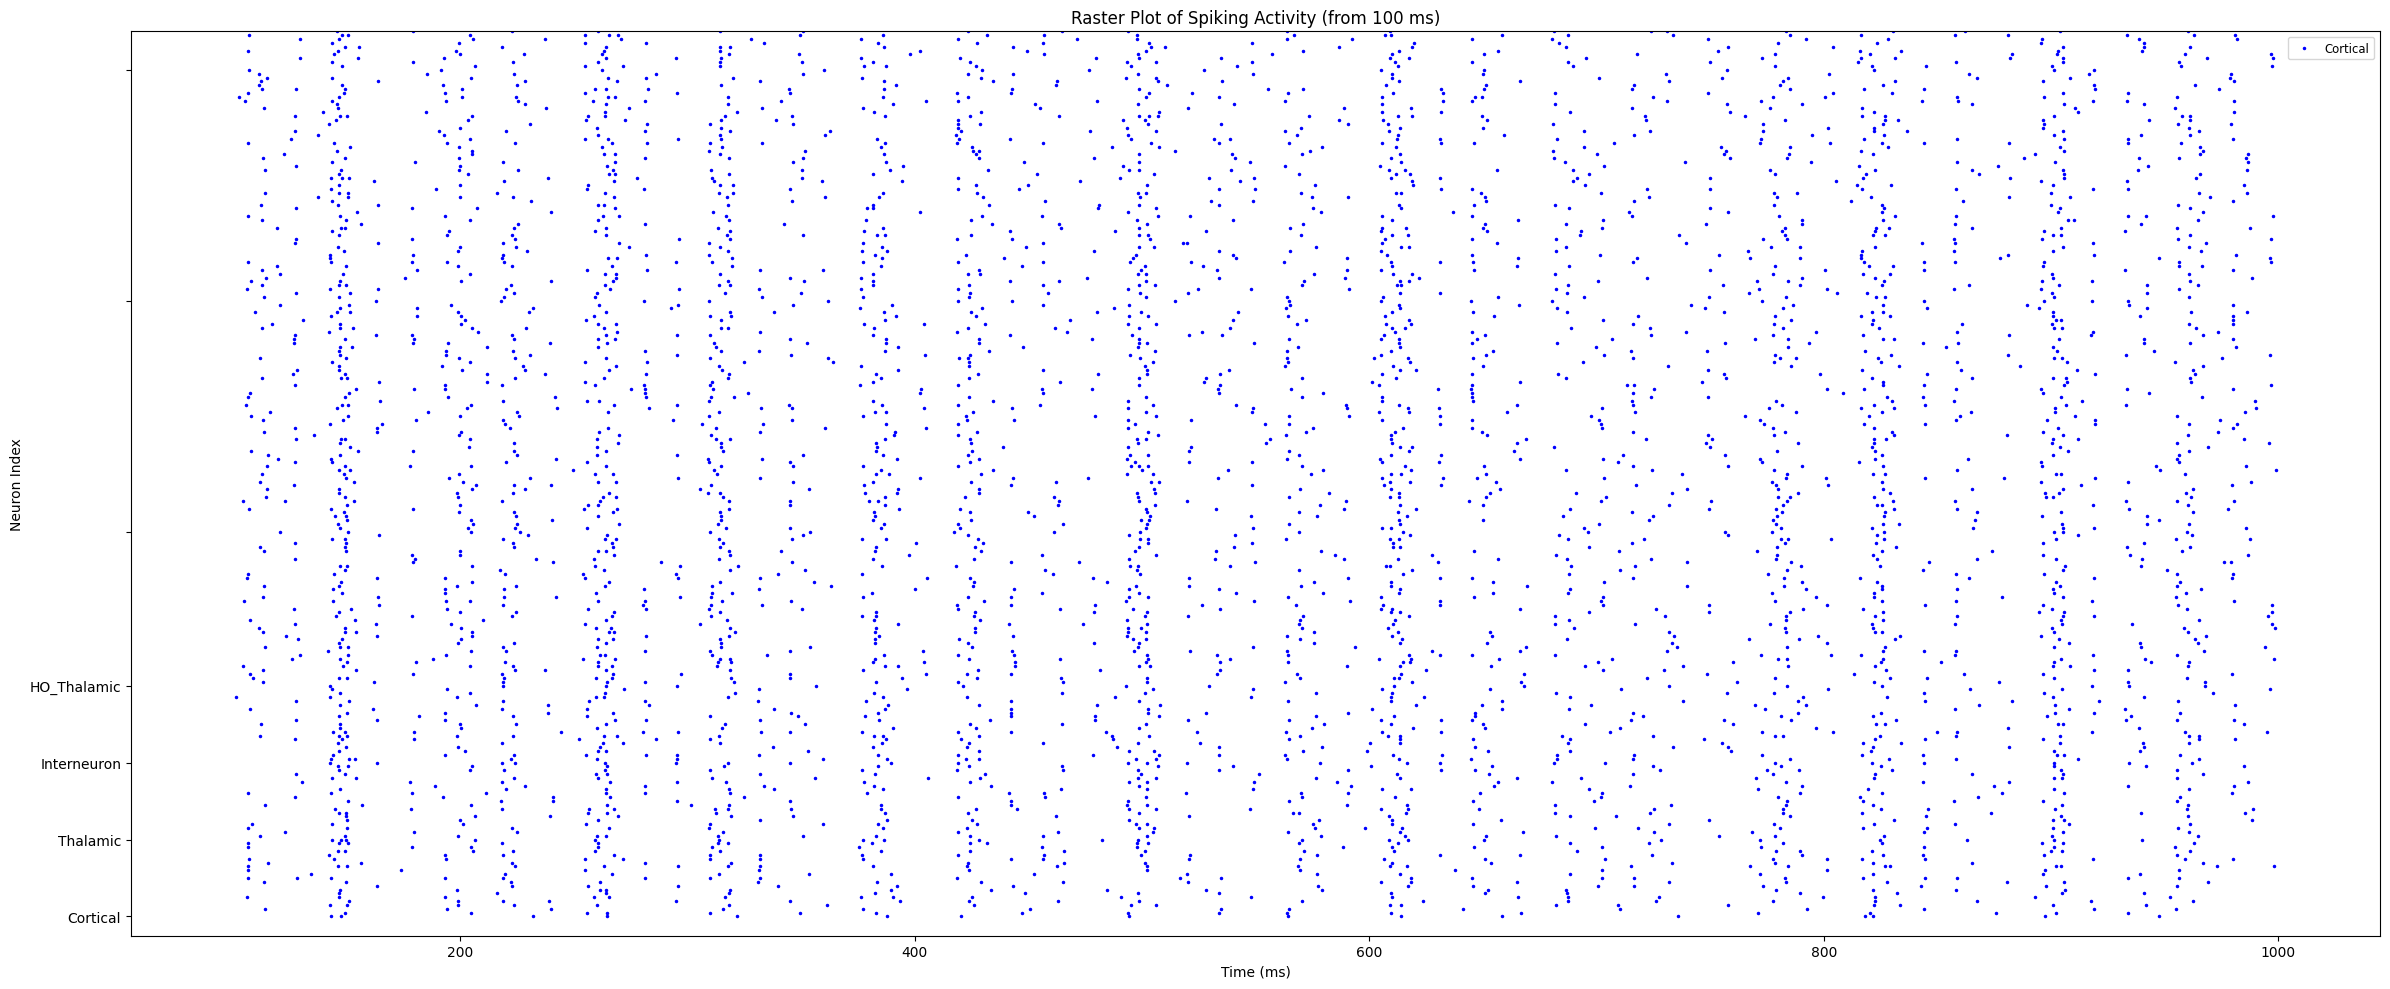

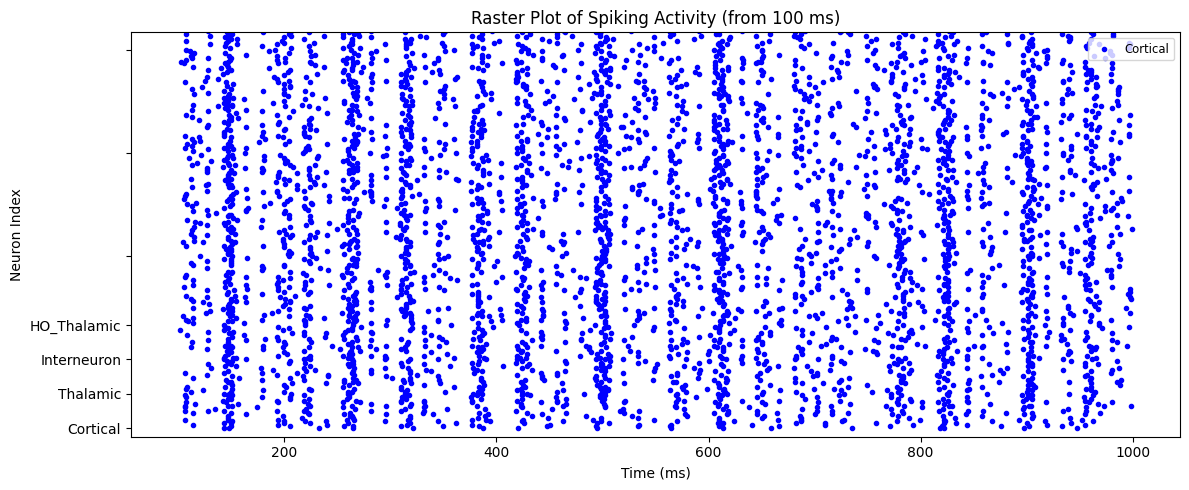

In [114]:
start_scope()
defaultclock.dt = 0.1*ms

# Parameters

eqs = '''dv/dt = 0.04/mV/ms * v**2 + 5/ms * v + 140*mV/ms - u/ms + I/(100*pF) + sigma*xi*(mV/ms**0.5) : volt
         du/dt = a*(b*v - u)/ms : volt
         I : amp
         sigma : 1
         a : 1
         b : 1
         c : volt
         d : volt
         '''
# Create a cortical neuron group
Cortical = NeuronGroup(650, eqs, threshold='v >= 30*mV', reset='v = c; u += d', method='milstein') 

Cortical.a = 0.02
Cortical.b = 0.2
Cortical.c = -65*mV
Cortical.d = 8*mV
Cortical.I = '0*pA' # Random background input to cortex 

Cortical.v = Cortical.c
Cortical.u = Cortical.b * -65*mV

# Create a low order thalamic neuron group (e.g., ventral posterior nucleus)
Thalamic = NeuronGroup(70, eqs, threshold='v >= 30*mV', reset='v = c; u += d', method='milstein')


Thalamic.a = 0.02
Thalamic.b = 0.25
Thalamic.c = -65*mV
Thalamic.d = 0.05*mV
Thalamic.I = '200*pA' # Only low order thalamic neurons are driven by sensory input

Thalamic.v = Thalamic.c
Thalamic.u = Thalamic.b * -65*mV

# Create a fast-spiking interneuron group
Interneuron = NeuronGroup(170, eqs, threshold='v >= 30*mV', reset='v = c; u += d', method='milstein')

Interneuron.a = 0.1
Interneuron.b = 0.2
Interneuron.c = -65*mV
Interneuron.d = 2*mV
Interneuron.I = '0*pA' # Interneurons are driven by cortex

Interneuron.v = Interneuron.c 
Interneuron.u = Interneuron.b * -65*mV

# Create a high order thalamic neuron group 
HO_Thalamic = NeuronGroup(130, eqs, threshold='v >= 30*mV', reset='v = c; u += d', method='milstein')
HO_Thalamic.a = 0.02
HO_Thalamic.b = 0.25
HO_Thalamic.c = -65*mV
HO_Thalamic.d = 0.05*mV
HO_Thalamic.I = '0*pA' # High-order thalamic neurons are driven by cortex 

HO_Thalamic.v = HO_Thalamic.c
HO_Thalamic.u = HO_Thalamic.b * -65*mV

# Random noise

Cortical.sigma = 6.0    # tune this — higher = more irregular firing
Interneuron.sigma = 1.5
HO_Thalamic.sigma = 1.0
Thalamic.sigma = 0.5  

# Create synapses

Cortical_to_Cortical = Synapses(Cortical, Cortical, 'w : volt', on_pre='v += w')
Cortical_to_Cortical.connect(condition= 'i!=j', p=0.15)
Cortical_to_Cortical.w = '0.5*mV + 0.5*mV*rand()'

Cortical_to_Thalamic = Synapses(Cortical, Thalamic, 'w : volt', on_pre='v += w')
Cortical_to_Thalamic.connect( p=0.05)
Cortical_to_Thalamic.w = '1*mV + 0.3*mV*rand()'

Cortical_to_HO_Thalamic = Synapses(Cortical, HO_Thalamic, 'w : volt', on_pre='v += w')
Cortical_to_HO_Thalamic.connect(p=0.05)
Cortical_to_HO_Thalamic.w = '2*mV + 1*mV*rand()'

Cortical_to_Interneuron = Synapses(Cortical, Interneuron, 'w : volt', on_pre='v += w')
Cortical_to_Interneuron.connect(p=0.2)
Cortical_to_Interneuron.w = '2*mV + 0.5*mV*rand()' # This weight is very important 

Thalamic_to_Cortical = Synapses(Thalamic, Cortical, 'w : volt', on_pre='v += w')
Thalamic_to_Cortical.connect(p=0.15)
Thalamic_to_Cortical.w = '3*mV + 2*mV*rand()' 

Thalamic_to_Interneuron = Synapses(Thalamic, Interneuron, 'w : volt', on_pre='v += w')
Thalamic_to_Interneuron.connect(p=0.2)
Thalamic_to_Interneuron.w = '1.5*mV + 1*mV*rand()'

Interneuron_to_Cortical = Synapses(Interneuron, Cortical, 'w : volt', on_pre='v += w')
Interneuron_to_Cortical.connect(p=0.2) 
Interneuron_to_Cortical.w = '-2*mV + (-0.5*mV*rand())'

Interneuron_to_Interneuron = Synapses(Interneuron, Interneuron, 'w : volt', on_pre='v += w')
Interneuron_to_Interneuron.connect(condition = 'i!=j', p=0.4)
Interneuron_to_Interneuron.w = '-0.5*mV + (-1*mV*rand())'

Interneuron_to_Thalamic = Synapses(Interneuron, Thalamic, 'w : volt', on_pre='v += w')
Interneuron_to_Thalamic.connect(p=0.2)
Interneuron_to_Thalamic.w = '-1*mV + (-1*mV*rand())'

HO_Thalamic_to_Cortical = Synapses(HO_Thalamic, Cortical, 'w : volt', on_pre='v += w')
HO_Thalamic_to_Cortical.connect(p=0.2)
HO_Thalamic_to_Cortical.w = '2*mV + 1*mV*rand()' # I can regulate bursting activity adjusting this weight (best is 2mV)

HO_to_Interneuron = Synapses(HO_Thalamic, Interneuron, 'w : volt', on_pre='v += w')
HO_to_Interneuron.connect(p=0.04)
HO_to_Interneuron.w = '1.5*mV + 0.5*mV*rand()'

# Record the results
MC = StateMonitor(Cortical, 'v', record=True)
MT = StateMonitor(Thalamic, 'v', record=True)
MI = StateMonitor(Interneuron, 'v', record=True)
MR = StateMonitor(HO_Thalamic, 'v', record=True)

Spikemon_Cortical = SpikeMonitor(Cortical)
Spikemon_Thalamic = SpikeMonitor(Thalamic)
Spikemon_Interneuron = SpikeMonitor(Interneuron)
Spikemon_HO_Thalamic = SpikeMonitor(HO_Thalamic)

print(f"Thalamic→Cortical synapses: {len(Thalamic_to_Cortical)}")
print(f"Avg thalamic inputs per cortical neuron: {len(Thalamic_to_Cortical)/50:.1f}")
print(f"Cortical dv/dt at rest with I=50pA: {(0.04*(-65)**2 + 5*(-65) + 140 + 50e-12/1e-10):.2f} mV/ms")

run(1000*ms)

duration = 1000*ms  # your post-trim window

rate_cortical = Spikemon_Cortical.num_spikes / (650 * duration)
rate_thalamic = Spikemon_Thalamic.num_spikes / (70 * duration)
rate_interneuron = Spikemon_Interneuron.num_spikes / (170 * duration)
rate_HO = Spikemon_HO_Thalamic.num_spikes / (130 * duration)

print(f"Cortical E:    {rate_cortical:.1f} Hz")
print(f"LO Thalamic:   {rate_thalamic:.1f} Hz")
print(f"Interneuron:   {rate_interneuron:.1f} Hz")
print(f"HO Thalamic:   {rate_HO:.1f} Hz")

# Trim the first 100 ms from plots
trim_ms = 100
trim_mask = (MC.t/ms >= trim_ms)
trim_idx = np.nonzero(trim_mask)[0]

# Plot the results
plt.figure(figsize=(20, 20))
plt.subplot(3, 1, 1)
plt.plot((MC.t/ms)[trim_idx], (MC.v[0]/mV)[trim_idx], label='Cortical Neuron')
#plt.plot((MT.t/ms)[trim_idx], (MT.v[0]/mV)[trim_idx], label='Thalamic Neuron')
#plt.plot((MI.t/ms)[trim_idx], (MI.v[0]/mV)[trim_idx], label='Interneuron')
#plt.plot((MR.t/ms)[trim_idx], (MR.v[0]/mV)[trim_idx], label='HO_Thalamic Neuron')
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (mV)')
plt.legend()
plt.title('Neural Activity (from 100 ms)')
plt.show()

# Plot the raster plot
plt.figure(figsize=(24, 10))
plt.plot((Spikemon_Cortical.t/ms)[Spikemon_Cortical.t/ms >= trim_ms], Spikemon_Cortical.i[Spikemon_Cortical.t/ms >= trim_ms], marker='.', linestyle='None', color='blue', markersize=3, label='Cortical')
#plt.plot((Spikemon_Thalamic.t/ms)[Spikemon_Thalamic.t/ms >= trim_ms], Spikemon_Thalamic.i[Spikemon_Thalamic.t/ms >= trim_ms] + 20, marker='.', linestyle='None', color='orange', markersize=3, label='Thalamic')
#plt.plot((Spikemon_Interneuron.t/ms)[Spikemon_Interneuron.t/ms >= trim_ms], Spikemon_Interneuron.i[Spikemon_Interneuron.t/ms >= trim_ms] + 40, marker='.', linestyle='None', color='green', markersize=3, label='Interneuron')
#plt.plot((Spikemon_HO_Thalamic.t/ms)[Spikemon_HO_Thalamic.t/ms >= trim_ms], Spikemon_HO_Thalamic.i[Spikemon_HO_Thalamic.t/ms >= trim_ms] + 60, marker='.', linestyle='None', color='purple', markersize=3, label='HO_Thalamic')
plt.xlabel('Time (ms)')
plt.ylabel('Neuron Index')
plt.ylim(-5, 230)
plt.yticks([0, 20, 40, 60, 100, 160, 220], ['Cortical', 'Thalamic', 'Interneuron', 'HO_Thalamic', '', '', ''])
plt.legend(loc='upper right', fontsize='small')
plt.title('Raster Plot of Spiking Activity (from 100 ms)')
plt.tight_layout()
plt.show()

# Plot the raster plot
plt.figure(figsize=(12, 5))  # was (24, 10)
plt.plot(
    (Spikemon_Cortical.t/ms)[Spikemon_Cortical.t/ms >= trim_ms],
    Spikemon_Cortical.i[Spikemon_Cortical.t/ms >= trim_ms],
    marker='.', linestyle='None', color='blue', markersize=6,  # was 3
    label='Cortical'
)

plt.xlabel('Time (ms)')
plt.ylabel('Neuron Index')
plt.ylim(-5, 230)
plt.yticks([0, 20, 40, 60, 100, 160, 220], ['Cortical', 'Thalamic', 'Interneuron', 'HO_Thalamic', '', '', ''])
plt.legend(loc='upper right', fontsize='small')
plt.title('Raster Plot of Spiking Activity (from 100 ms)')
plt.tight_layout()
plt.show()



Vana mudel, jätsin igaks juhuks. 

WARNING    Cannot use Cython, a test compilation failed: Cython is not available (ImportError) [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]
INFO       Cannot use compiled code, falling back to the numpy code generation target. Note that this will likely be slower than using compiled code. Set the code generation to numpy manually to avoid this message:
prefs.codegen.target = "numpy" [brian2.devices.device.codegen_fallback]


Thalamic→Cortical synapses: 6789
Avg thalamic inputs per cortical neuron: 135.8
Cortical dv/dt at rest with I=50pA: -15.50 mV/ms
Cortical E:    12.8 Hz
LO Thalamic:   19.8 Hz
Interneuron:   46.7 Hz
HO Thalamic:   17.5 Hz


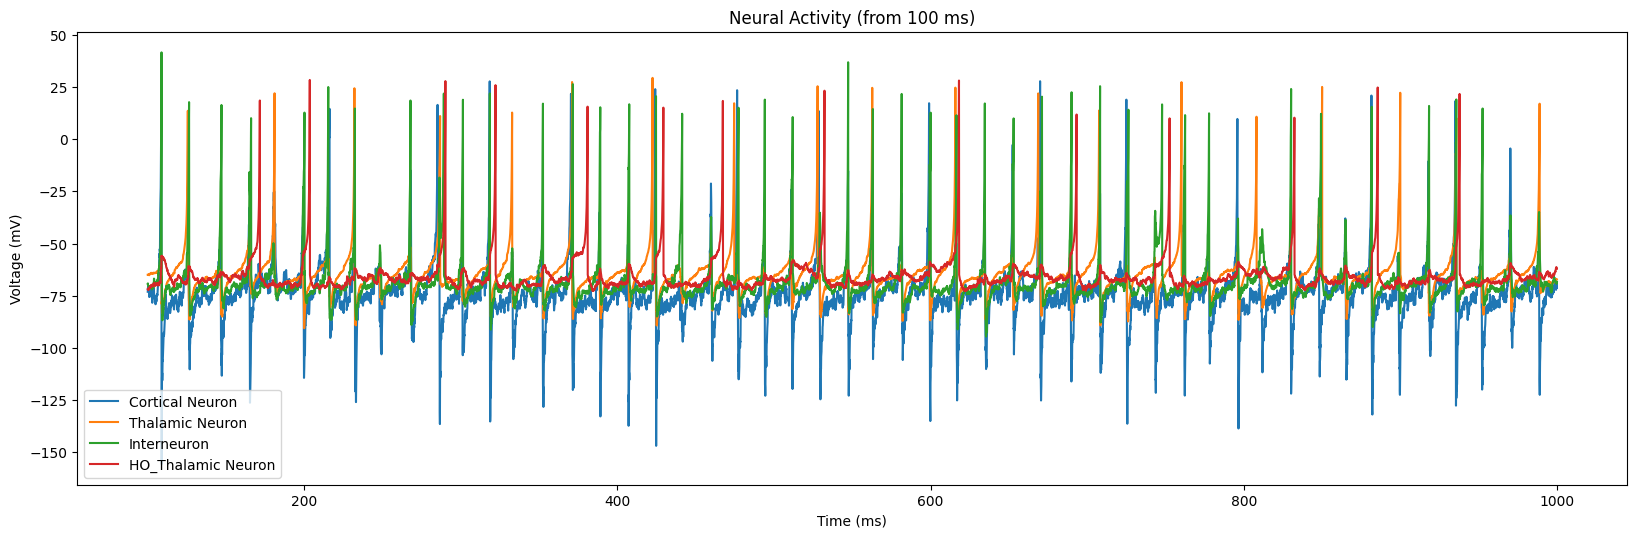

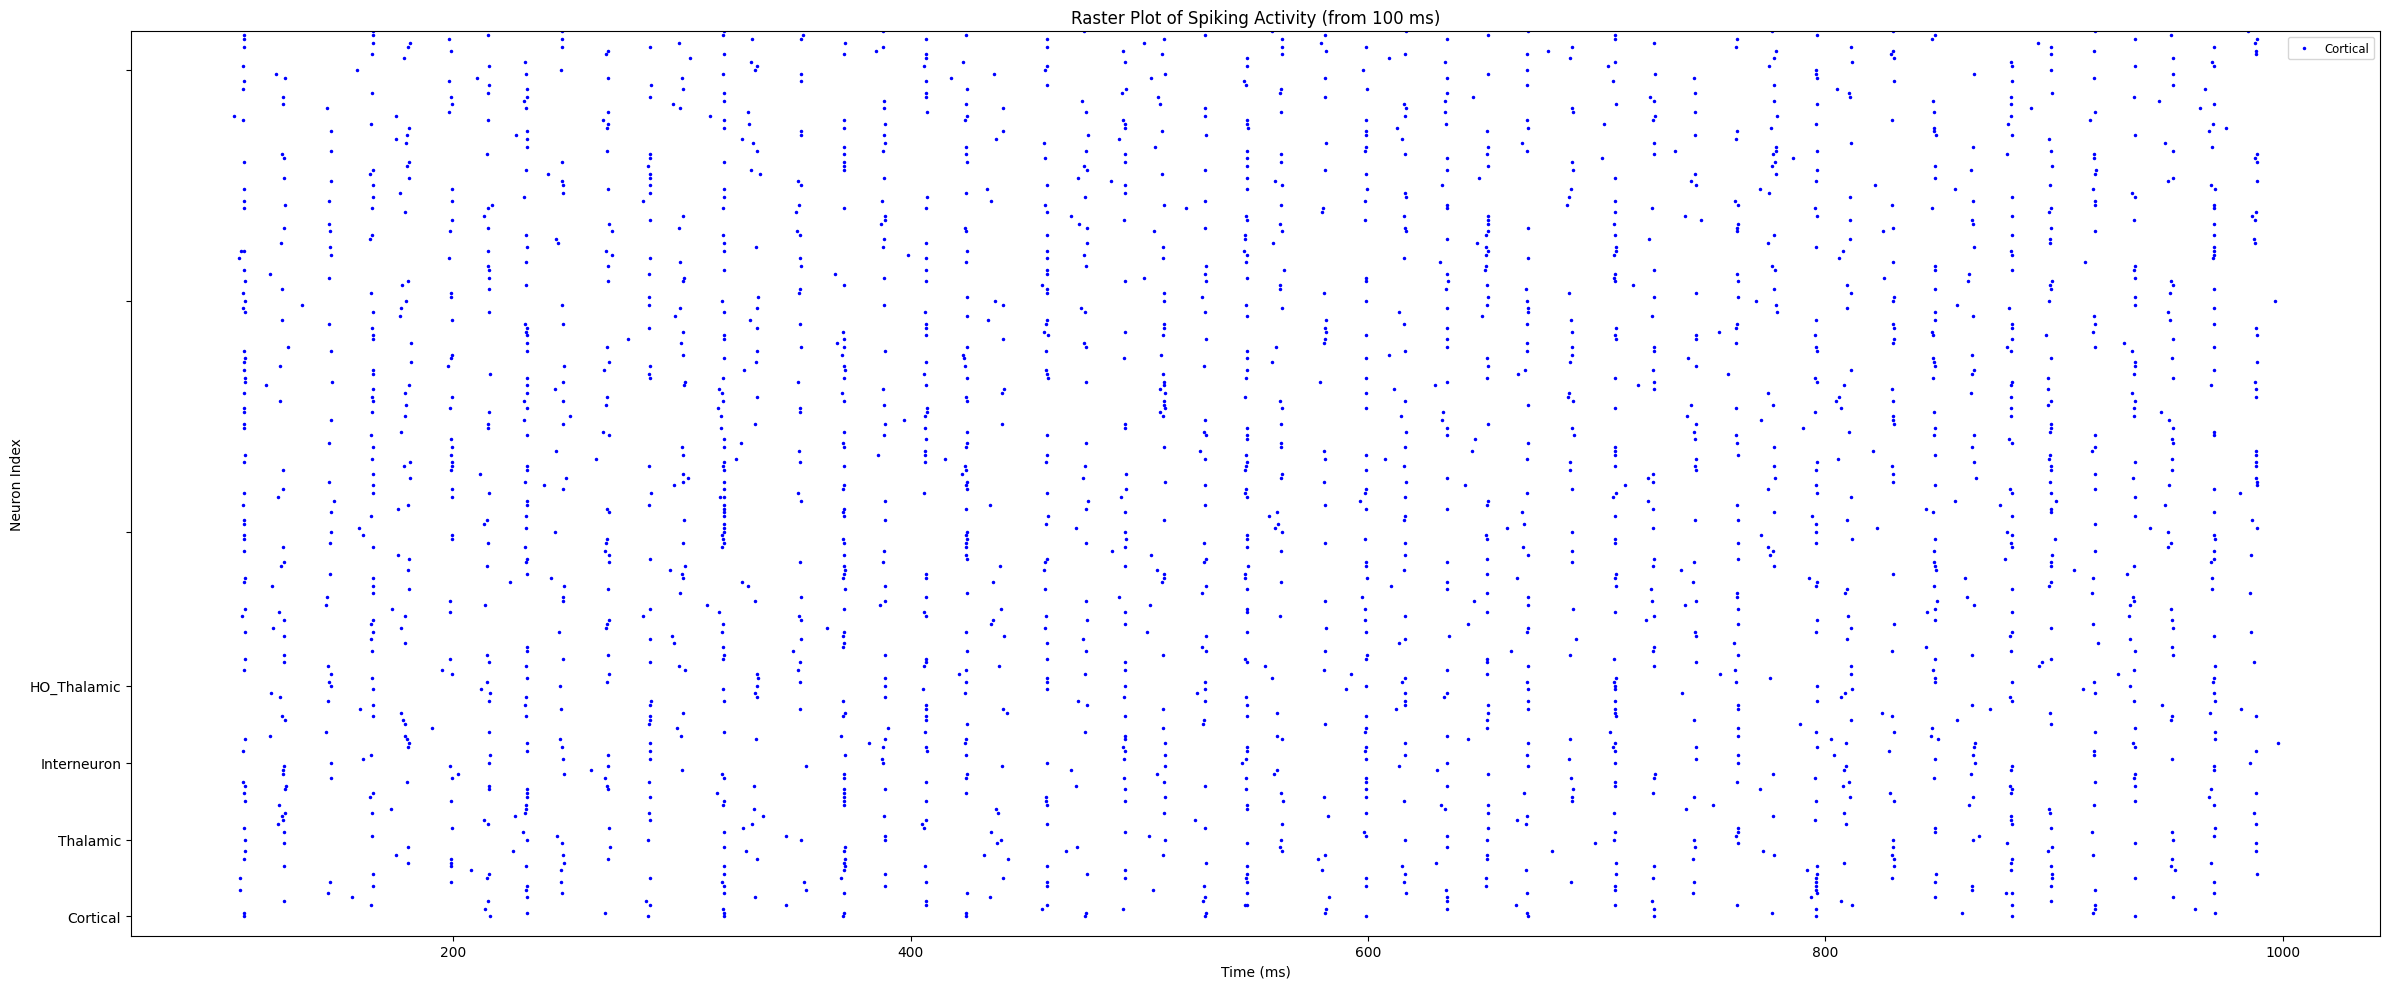

In [3]:
start_scope()

# Parameters

eqs = '''dv/dt = 0.04/mV/ms * v**2 + 5/ms * v + 140*mV/ms - u/ms + I/(100*pF) + sigma*xi*(mV/ms**0.5) : volt
         du/dt = a*(b*v - u)/ms : volt
         I : amp
         sigma : 1
         a : 1
         b : 1
         c : volt
         d : volt
         '''
# Create a cortical neuron group
Cortical = NeuronGroup(650, eqs, threshold='v >= 30*mV', reset='v = c; u += d', method='milstein') 

Cortical.a = 0.02
Cortical.b = 0.2
Cortical.c = -65*mV
Cortical.d = 8*mV
Cortical.I = '100*pA' # Random background input to cortex 

Cortical.v = Cortical.c
Cortical.u = Cortical.b * -65*mV

# Create a low order thalamic neuron group (e.g., ventral posterior nucleus)
Thalamic = NeuronGroup(70, eqs, threshold='v >= 30*mV', reset='v = c; u += d', method='milstein')


Thalamic.a = 0.02
Thalamic.b = 0.25
Thalamic.c = -65*mV
Thalamic.d = 2*mV
Thalamic.I = '200*pA' # Only low order thalamic neurons are driven by sensory input

Thalamic.v = Thalamic.c
Thalamic.u = Thalamic.b * -65*mV

# Create a fast-spiking interneuron group
Interneuron = NeuronGroup(170, eqs, threshold='v >= 30*mV', reset='v = c; u += d', method='milstein')

Interneuron.a = 0.1
Interneuron.b = 0.2
Interneuron.c = -65*mV
Interneuron.d = 2*mV
Interneuron.I = '0*pA' # Interneurons are driven by cortex

Interneuron.v = Interneuron.c 
Interneuron.u = Interneuron.b * -65*mV

# Create a high order thalamic neuron group 
HO_Thalamic = NeuronGroup(130, eqs, threshold='v >= 30*mV', reset='v = c; u += d', method='milstein')
HO_Thalamic.a = 0.02
HO_Thalamic.b = 0.25
HO_Thalamic.c = -65*mV
HO_Thalamic.d = 2*mV
HO_Thalamic.I = '0*pA' # High-order thalamic neurons are driven by cortex 

HO_Thalamic.v = HO_Thalamic.c
HO_Thalamic.u = HO_Thalamic.b * -65*mV

# Random noise

Cortical.sigma = 4.0    # tune this — higher = more irregular firing
Interneuron.sigma = 1.5
HO_Thalamic.sigma = 1.0
Thalamic.sigma = 0.5  

# Create synapses

Cortical_to_Cortical = Synapses(Cortical, Cortical, 'w : volt', on_pre='v += w')
Cortical_to_Cortical.connect(condition= 'i!=j', p=0.15)
Cortical_to_Cortical.w = '2*mV + 0.5*mV*rand()' # Changing this weight and cortical to interneuron weight are ways to make cortical firing more or less uniform 
Cortical_to_Thalamic = Synapses(Cortical, Thalamic, 'w : volt', on_pre='v += w')
Cortical_to_Thalamic.connect( p=0.05)
Cortical_to_Thalamic.w = '1*mV + 0.3*mV*rand()'

Cortical_to_HO_Thalamic = Synapses(Cortical, HO_Thalamic, 'w : volt', on_pre='v += w')
Cortical_to_HO_Thalamic.connect(p=0.05)
Cortical_to_HO_Thalamic.w = '1*mV + 1*mV*rand()'

Cortical_to_Interneuron = Synapses(Cortical, Interneuron, 'w : volt', on_pre='v += w')
Cortical_to_Interneuron.connect(p=0.2)
Cortical_to_Interneuron.w = '2*mV + 0.5*mV*rand()' # This weight is very important 

Thalamic_to_Cortical = Synapses(Thalamic, Cortical, 'w : volt', on_pre='v += w')
Thalamic_to_Cortical.connect(p=0.15)
Thalamic_to_Cortical.w = '4*mV + 2*mV*rand()' 

Thalamic_to_Interneuron = Synapses(Thalamic, Interneuron, 'w : volt', on_pre='v += w')
Thalamic_to_Interneuron.connect(p=0.2)
Thalamic_to_Interneuron.w = '1.5*mV + 1*mV*rand()'

Interneuron_to_Cortical = Synapses(Interneuron, Cortical, 'w : volt', on_pre='v += w')
Interneuron_to_Cortical.connect(p=0.4) 
Interneuron_to_Cortical.w = '-3*mV + (-0.5*mV*rand())'

Interneuron_to_Interneuron = Synapses(Interneuron, Interneuron, 'w : volt', on_pre='v += w')
Interneuron_to_Interneuron.connect(condition = 'i!=j', p=0.4)
Interneuron_to_Interneuron.w = '-0.5*mV + (-1*mV*rand())'

Interneuron_to_Thalamic = Synapses(Interneuron, Thalamic, 'w : volt', on_pre='v += w')
Interneuron_to_Thalamic.connect(p=0.2)
Interneuron_to_Thalamic.w = '-1*mV + (-1*mV*rand())'

HO_Thalamic_to_Cortical = Synapses(HO_Thalamic, Cortical, 'w : volt', on_pre='v += w')
HO_Thalamic_to_Cortical.connect(p=0.02)
HO_Thalamic_to_Cortical.w = '6*mV + 1*mV*rand()'

HO_to_Interneuron = Synapses(HO_Thalamic, Interneuron, 'w : volt', on_pre='v += w')
HO_to_Interneuron.connect(p=0.04)
HO_to_Interneuron.w = '1.5*mV + 0.5*mV*rand()'

# Record the results
MC = StateMonitor(Cortical, 'v', record=True)
MT = StateMonitor(Thalamic, 'v', record=True)
MI = StateMonitor(Interneuron, 'v', record=True)
MR = StateMonitor(HO_Thalamic, 'v', record=True)

Spikemon_Cortical = SpikeMonitor(Cortical)
Spikemon_Thalamic = SpikeMonitor(Thalamic)
Spikemon_Interneuron = SpikeMonitor(Interneuron)
Spikemon_HO_Thalamic = SpikeMonitor(HO_Thalamic)

print(f"Thalamic→Cortical synapses: {len(Thalamic_to_Cortical)}")
print(f"Avg thalamic inputs per cortical neuron: {len(Thalamic_to_Cortical)/50:.1f}")
print(f"Cortical dv/dt at rest with I=50pA: {(0.04*(-65)**2 + 5*(-65) + 140 + 50e-12/1e-10):.2f} mV/ms")

run(1000*ms)

duration = 1000*ms  # your post-trim window

rate_cortical = Spikemon_Cortical.num_spikes / (650 * duration)
rate_thalamic = Spikemon_Thalamic.num_spikes / (70 * duration)
rate_interneuron = Spikemon_Interneuron.num_spikes / (170 * duration)
rate_HO = Spikemon_HO_Thalamic.num_spikes / (130 * duration)

print(f"Cortical E:    {rate_cortical:.1f} Hz")
print(f"LO Thalamic:   {rate_thalamic:.1f} Hz")
print(f"Interneuron:   {rate_interneuron:.1f} Hz")
print(f"HO Thalamic:   {rate_HO:.1f} Hz")

# Trim the first 100 ms from plots
trim_ms = 100
trim_mask = (MC.t/ms >= trim_ms)
trim_idx = np.nonzero(trim_mask)[0]

# Plot the results
plt.figure(figsize=(20, 20))
plt.subplot(3, 1, 1)
plt.plot((MC.t/ms)[trim_idx], (MC.v[0]/mV)[trim_idx], label='Cortical Neuron')
plt.plot((MT.t/ms)[trim_idx], (MT.v[0]/mV)[trim_idx], label='Thalamic Neuron')
plt.plot((MI.t/ms)[trim_idx], (MI.v[0]/mV)[trim_idx], label='Interneuron')
plt.plot((MR.t/ms)[trim_idx], (MR.v[0]/mV)[trim_idx], label='HO_Thalamic Neuron')
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (mV)')
plt.legend()
plt.title('Neural Activity (from 100 ms)')
plt.show()

# Plot the raster plot
plt.figure(figsize=(24, 10))
plt.plot((Spikemon_Cortical.t/ms)[Spikemon_Cortical.t/ms >= trim_ms], Spikemon_Cortical.i[Spikemon_Cortical.t/ms >= trim_ms], marker='.', linestyle='None', color='blue', markersize=3, label='Cortical')
#plt.plot((Spikemon_Thalamic.t/ms)[Spikemon_Thalamic.t/ms >= trim_ms], Spikemon_Thalamic.i[Spikemon_Thalamic.t/ms >= trim_ms] + 20, marker='.', linestyle='None', color='orange', markersize=3, label='Thalamic')
#plt.plot((Spikemon_Interneuron.t/ms)[Spikemon_Interneuron.t/ms >= trim_ms], Spikemon_Interneuron.i[Spikemon_Interneuron.t/ms >= trim_ms] + 40, marker='.', linestyle='None', color='green', markersize=3, label='Interneuron')
#plt.plot((Spikemon_HO_Thalamic.t/ms)[Spikemon_HO_Thalamic.t/ms >= trim_ms], Spikemon_HO_Thalamic.i[Spikemon_HO_Thalamic.t/ms >= trim_ms] + 60, marker='.', linestyle='None', color='purple', markersize=3, label='HO_Thalamic')
plt.xlabel('Time (ms)')
plt.ylabel('Neuron Index')
plt.ylim(-5, 230)
plt.yticks([0, 20, 40, 60, 100, 160, 220], ['Cortical', 'Thalamic', 'Interneuron', 'HO_Thalamic', '', '', ''])
plt.legend(loc='upper right', fontsize='small')
plt.title('Raster Plot of Spiking Activity (from 100 ms)')
plt.tight_layout()
plt.show()

